# Phase 2: Exploratory Data Analysis

Goal: Explore team-level NBA statistics, identify patterns, and understand which stats may help predict team success.

### Checking Dataset

In [1]:
import pandas as pd

df = pd.read_csv("../data/processed/team_stats_clean.csv")
df.head()

,TEAM_ID,TEAM_NAME,GP,W,L,W_PCT,MIN,FGM,FGA,FG_PCT,...,REB_RANK,AST_RANK,TOV_RANK,STL_RANK,BLK_RANK,BLKA_RANK,PF_RANK,PFD_RANK,PTS_RANK,PLUS_MINUS_RANK
0,1610612737,Atlanta Hawks,82,46,36,0.561,3951.0,3575,7541,0.474,...,18,1,10,5,18,17,14,26,6,12
1,1610612738,Boston Celtics,82,56,26,0.683,3946.0,3456,7398,0.467,...,3,27,1,28,11,3,9,27,19,4
2,1610612751,Brooklyn Nets,82,20,62,0.244,3951.0,3071,6933,0.443,...,30,26,29,22,23,23,26,21,30,28
3,1610612766,Charlotte Hornets,82,44,38,0.537,3951.0,3357,7292,0.460,...,5,15,25,29,21,9,10,18,13,8
4,1610612741,Chicago Bulls,82,31,51,0.378,3951.0,3476,7417,0.469,...,9,7,23,23,11,26,8,24,12,22


In [2]:
df.shape

(30, 54)

In [3]:
df.head()

,TEAM_ID,TEAM_NAME,GP,W,L,W_PCT,MIN,FGM,FGA,FG_PCT,...,REB_RANK,AST_RANK,TOV_RANK,STL_RANK,BLK_RANK,BLKA_RANK,PF_RANK,PFD_RANK,PTS_RANK,PLUS_MINUS_RANK
0,1610612737,Atlanta Hawks,82,46,36,0.561,3951.0,3575,7541,0.474,...,18,1,10,5,18,17,14,26,6,12
1,1610612738,Boston Celtics,82,56,26,0.683,3946.0,3456,7398,0.467,...,3,27,1,28,11,3,9,27,19,4
2,1610612751,Brooklyn Nets,82,20,62,0.244,3951.0,3071,6933,0.443,...,30,26,29,22,23,23,26,21,30,28
3,1610612766,Charlotte Hornets,82,44,38,0.537,3951.0,3357,7292,0.460,...,5,15,25,29,21,9,10,18,13,8
4,1610612741,Chicago Bulls,82,31,51,0.378,3951.0,3476,7417,0.469,...,9,7,23,23,11,26,8,24,12,22


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 54 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   TEAM_ID          30 non-null     int64  
 1   TEAM_NAME        30 non-null     str    
 2   GP               30 non-null     int64  
 3   W                30 non-null     int64  
 4   L                30 non-null     int64  
 5   W_PCT            30 non-null     float64
 6   MIN              30 non-null     float64
 7   FGM              30 non-null     int64  
 8   FGA              30 non-null     int64  
 9   FG_PCT           30 non-null     float64
 10  FG3M             30 non-null     int64  
 11  FG3A             30 non-null     int64  
 12  FG3_PCT          30 non-null     float64
 13  FTM              30 non-null     int64  
 14  FTA              30 non-null     int64  
 15  FT_PCT           30 non-null     float64
 16  OREB             30 non-null     int64  
 17  DREB             30 non-null 

In [5]:
df.isnull().sum()

TEAM_ID            0
TEAM_NAME          0
GP                 0
W                  0
L                  0
W_PCT              0
MIN                0
FGM                0
FGA                0
FG_PCT             0
FG3M               0
FG3A               0
FG3_PCT            0
FTM                0
FTA                0
FT_PCT             0
OREB               0
DREB               0
REB                0
AST                0
TOV                0
STL                0
BLK                0
BLKA               0
PF                 0
PFD                0
PTS                0
PLUS_MINUS         0
GP_RANK            0
W_RANK             0
L_RANK             0
W_PCT_RANK         0
MIN_RANK           0
FGM_RANK           0
FGA_RANK           0
FG_PCT_RANK        0
FG3M_RANK          0
FG3A_RANK          0
FG3_PCT_RANK       0
FTM_RANK           0
FTA_RANK           0
FT_PCT_RANK        0
OREB_RANK          0
DREB_RANK          0
REB_RANK           0
AST_RANK           0
TOV_RANK           0
STL_RANK     

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.describe()

,TEAM_ID,GP,W,L,W_PCT,MIN,FGM,FGA,FG_PCT,FG3M,...,REB_RANK,AST_RANK,TOV_RANK,STL_RANK,BLK_RANK,BLKA_RANK,PF_RANK,PFD_RANK,PTS_RANK,PLUS_MINUS_RANK
count,3.000000e+01,30.0,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,...,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000
mean,1.610613e+09,82.0,41.000000,41.000000,0.499967,3956.663556,3440.900000,7305.333333,0.471067,1090.566667,...,15.500000,15.466667,15.400000,15.400000,15.466667,15.433333,15.433333,15.400000,15.500000,15.500000
std,8.803408e+00,0.0,13.843958,13.843958,0.168850,11.276249,107.166435,180.602886,0.013193,128.932670,...,8.803408,8.756213,8.775357,8.853599,8.818997,8.799229,8.763889,8.810652,8.803408,8.803408
min,1.610613e+09,82.0,17.000000,18.000000,0.207000,3940.971667,3071.000000,6857.000000,0.443000,843.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,1.610613e+09,82.0,27.250000,30.000000,0.332250,3951.000000,3362.250000,7265.000000,0.462250,980.250000,...,8.250000,8.250000,8.250000,8.250000,8.250000,8.250000,8.250000,8.250000,8.250000,8.250000
50%,1.610613e+09,82.0,44.500000,37.500000,0.543000,3951.000000,3451.500000,7351.000000,0.467500,1119.500000,...,15.500000,15.500000,15.000000,15.000000,15.500000,15.000000,15.500000,15.500000,15.500000,15.500000
75%,1.610613e+09,82.0,52.000000,54.750000,0.634000,3961.000000,3517.250000,7402.500000,0.481750,1172.000000,...,22.750000,22.750000,22.750000,22.750000,22.750000,22.750000,22.750000,22.500000,22.750000,22.750000
max,1.610613e+09,82.0,64.000000,65.000000,0.780000,3986.000000,3582.000000,7648.000000,0.502000,1343.000000,...,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000


## EDA  

In [8]:
corr = df.corr(numeric_only=True)
corr["W_PCT"].sort_values(ascending=False)

W_PCT              1.000000
W                  0.999999
PLUS_MINUS         0.972673
PTS                0.632059
FG_PCT             0.630078
FGM                0.551651
DREB               0.517601
REB                0.514901
FG3_PCT            0.443679
PFD                0.355075
BLK                0.288581
FT_PCT             0.245817
STL                0.216831
OREB               0.205318
FTM                0.199359
FG3M               0.175252
FGA_RANK           0.156344
MIN                0.144052
FTA                0.143575
AST                0.091639
FG3A               0.044804
FGA               -0.012111
FG3A_RANK         -0.047312
MIN_RANK          -0.055320
TEAM_ID           -0.085334
AST_RANK          -0.121502
FT_PCT_RANK       -0.179216
FTA_RANK          -0.184946
OREB_RANK         -0.187251
STL_RANK          -0.189597
FG3M_RANK         -0.190536
FTM_RANK          -0.206125
BLK_RANK          -0.234569
PF                -0.302888
PF_RANK           -0.341303
PFD_RANK          -0

### Heatmaps

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

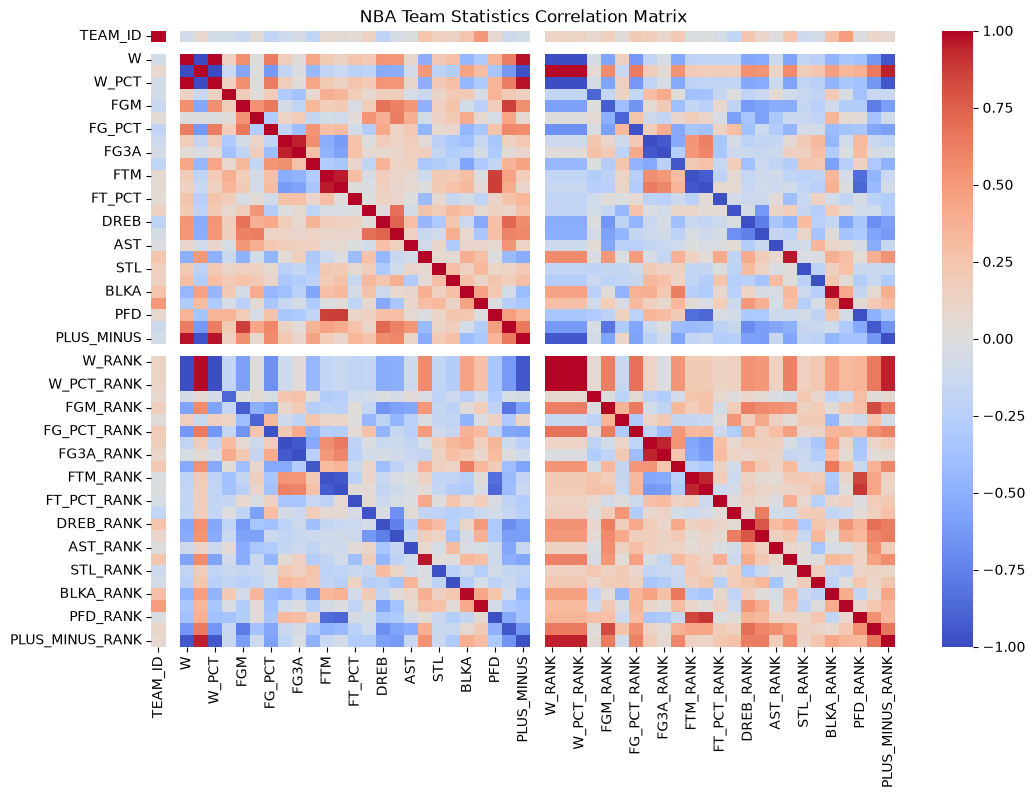

In [10]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    cmap="coolwarm",
    center=0
)

plt.title("NBA Team Statistics Correlation Matrix")
plt.show()

#### Looking only at W_PCT Correlations

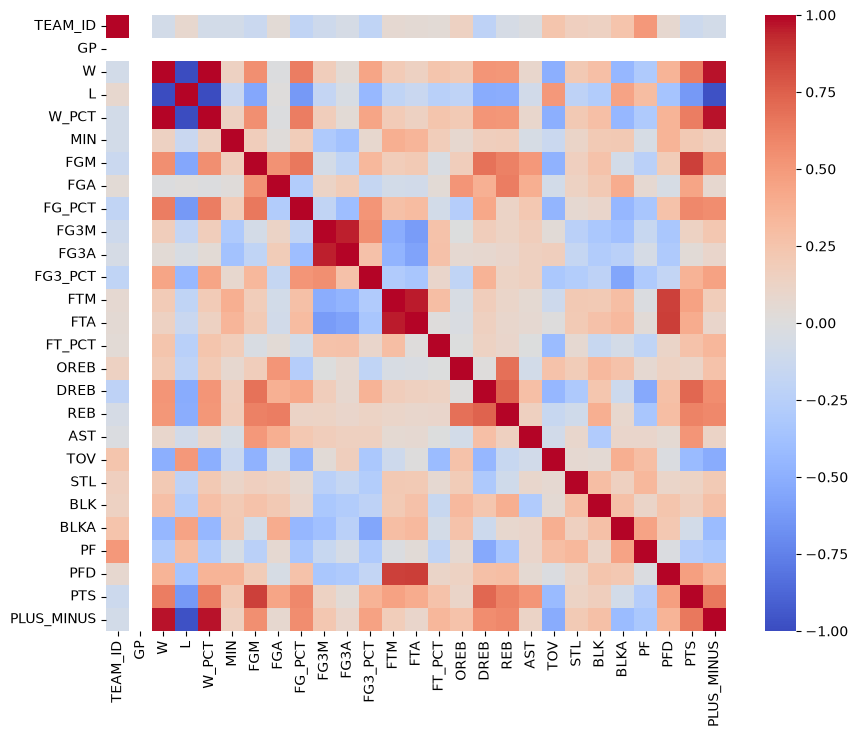

In [11]:
cols = [col for col in df.columns if "_RANK" not in col]
corr = df[cols].corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.show()

In [12]:
corr["W_PCT"].sort_values(ascending=False)

W_PCT         1.000000
W             0.999999
PLUS_MINUS    0.972673
PTS           0.632059
FG_PCT        0.630078
FGM           0.551651
DREB          0.517601
REB           0.514901
FG3_PCT       0.443679
PFD           0.355075
BLK           0.288581
FT_PCT        0.245817
STL           0.216831
OREB          0.205318
FTM           0.199359
FG3M          0.175252
MIN           0.144052
FTA           0.143575
AST           0.091639
FG3A          0.044804
FGA          -0.012111
TEAM_ID      -0.085334
PF           -0.302888
BLKA         -0.450861
TOV          -0.504125
L            -0.999999
GP                 NaN
Name: W_PCT, dtype: float64

#### Observations
- Plus/minus ****
- PTS ***
- REB **
- DREB **
- FG3_PCT **
- FG_PCT ***
- FGM **

- PLUS_MINUS exhibits the strongest positive relationship with win percentage (r = 0.973), suggesting that teams that consistently outscore opponents tend to achieve higher winning percentages.
- AST much lower than expected. Why?
- FG_PCT (r = 0.630) is more strongly associated with winning than three-point percentage (r = 0.444), suggesting that overall offensive efficiency may be more important than perimeter shooting alone.
- DREB tend to win more games, likely because defensive rebounds end opponent possessions and create additional offensive opportunities.
- Relating to DREB, TOV exhibit a moderate negative correlation with winning percentage (r = -0.504), indicating that teams that protect the basketball tend to be more successful.

### Scatter Plots

#### FG_PCT vs W_PCT

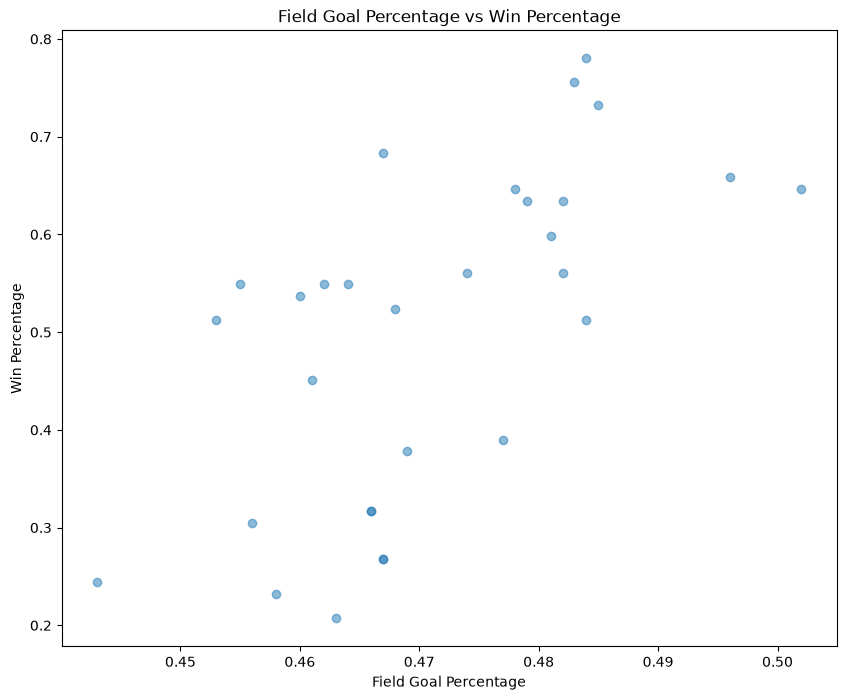

r = 0.630


In [13]:
# FG_PCT vs W_PCT
plt.figure(figsize=(10,8))
plt.scatter(df["FG_PCT"], df["W_PCT"], alpha=0.5)
plt.xlabel("Field Goal Percentage")
plt.ylabel("Win Percentage")
plt.title("Field Goal Percentage vs Win Percentage")
plt.show()

r = df["FG_PCT"].corr(df["W_PCT"])
print(f"r = {r:.3f}")

In [14]:
df[["TEAM_NAME", "FG_PCT", "W_PCT"]].sort_values("FG_PCT",ascending=False)

,TEAM_NAME,FG_PCT,W_PCT
13,Los Angeles Lakers,0.502,0.646
7,Denver Nuggets,0.496,0.659
8,Detroit Pistons,0.485,0.732
20,Oklahoma City Thunder,0.484,0.780
12,LA Clippers,0.484,0.512
26,San Antonio Spurs,0.483,0.756
27,Toronto Raptors,0.482,0.561
5,Cleveland Cavaliers,0.482,0.634
17,Minnesota Timberwolves,0.481,0.598
10,Houston Rockets,0.479,0.634


###### *Celtics higher W_PCT despite lower FG_PCT

#### TOV vs W_PCT

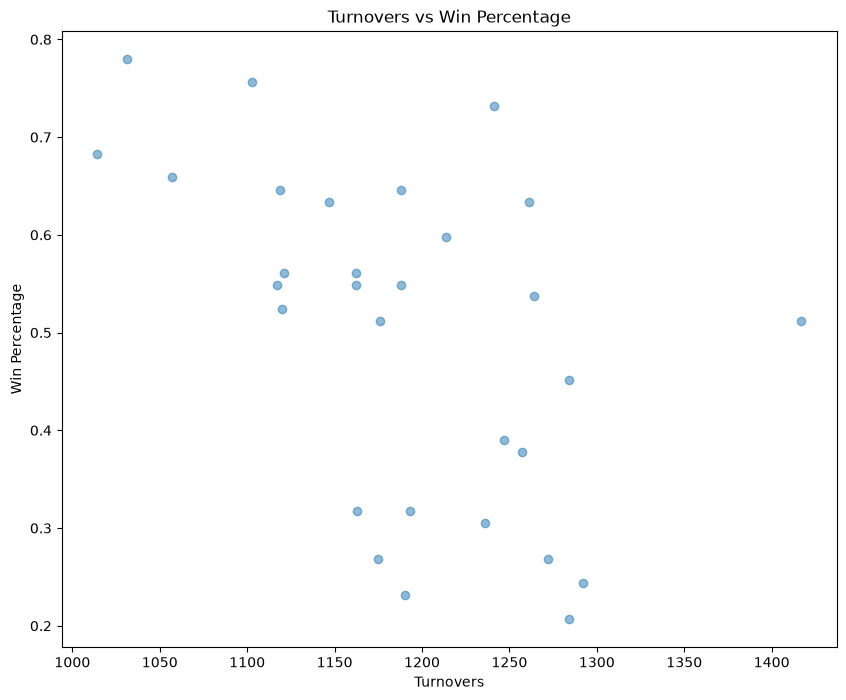

r = -0.504


In [15]:
# TOV vs W_PCT
plt.figure(figsize=(10,8))
plt.scatter(df["TOV"], df["W_PCT"], alpha=0.5)
plt.xlabel("Turnovers")
plt.ylabel("Win Percentage")
plt.title("Turnovers vs Win Percentage")
plt.show()

r = df["TOV"].corr(df["W_PCT"])
print(f"r = {r:.3f}")

In [16]:
df[["TEAM_NAME", "TOV", "W_PCT"]].sort_values("TOV",ascending=False)

,TEAM_NAME,TOV,W_PCT
24,Portland Trail Blazers,1417.0,0.512
2,Brooklyn Nets,1292.0,0.244
29,Washington Wizards,1284.0,0.207
9,Golden State Warriors,1284.0,0.451
28,Utah Jazz,1272.0,0.268
3,Charlotte Hornets,1264.0,0.537
10,Houston Rockets,1261.0,0.634
4,Chicago Bulls,1257.0,0.378
16,Milwaukee Bucks,1247.0,0.390
8,Detroit Pistons,1241.0,0.732


###### *Blazers, Hornets, Rockets, Pistons high W_PCT despite highest TOV


#### FG3_PCT vs W_PCT

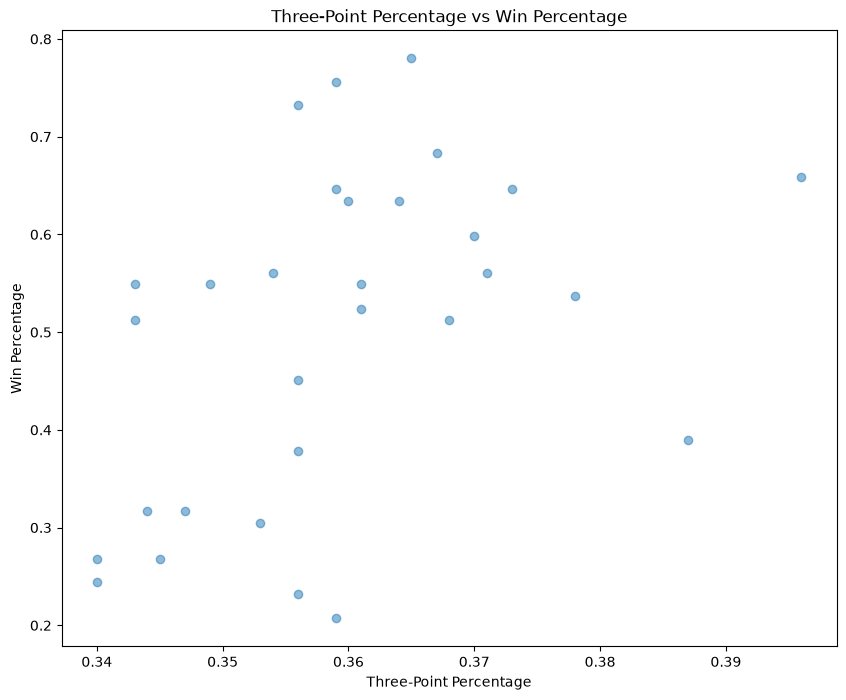

r = 0.444


In [17]:
# FG3_PCT vs W_PCT
plt.figure(figsize=(10,8))
plt.scatter(df["FG3_PCT"], df["W_PCT"], alpha=0.5)
plt.xlabel("Three-Point Percentage")
plt.ylabel("Win Percentage")
plt.title("Three-Point Percentage vs Win Percentage")
plt.show()

r = df["FG3_PCT"].corr(df["W_PCT"])

print(f"r = {r:.3f}")

In [18]:
df[["TEAM_NAME", "FG3_PCT", "W_PCT"]].sort_values("FG3_PCT",ascending=False)

,TEAM_NAME,FG3_PCT,W_PCT
7,Denver Nuggets,0.396,0.659
16,Milwaukee Bucks,0.387,0.390
3,Charlotte Hornets,0.378,0.537
19,New York Knicks,0.373,0.646
0,Atlanta Hawks,0.371,0.561
17,Minnesota Timberwolves,0.370,0.598
12,LA Clippers,0.368,0.512
1,Boston Celtics,0.367,0.683
20,Oklahoma City Thunder,0.365,0.780
10,Houston Rockets,0.364,0.634


#### DREB vs W_PCT

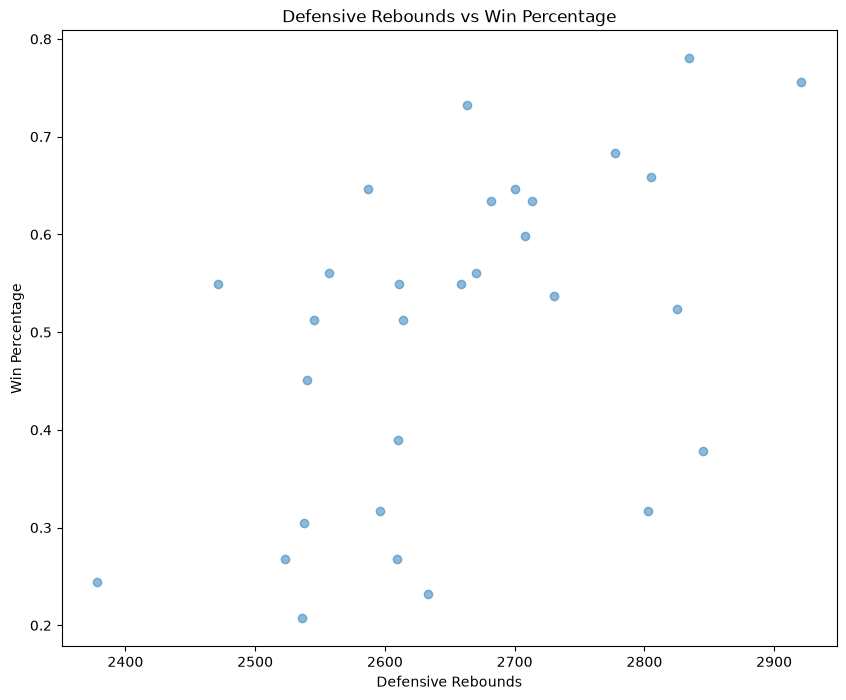

r = 0.518


In [19]:
# DREB vs W_PCT
plt.figure(figsize=(10,8))
plt.scatter(df["DREB"], df["W_PCT"], alpha=0.5)
plt.xlabel("Defensive Rebounds")
plt.ylabel("Win Percentage")
plt.title("Defensive Rebounds vs Win Percentage")
plt.show()

r = df["DREB"].corr(df["W_PCT"])

print(f"r = {r:.3f}")

In [20]:
df[["TEAM_NAME", "DREB", "W_PCT"]].sort_values("DREB",ascending=False)

,TEAM_NAME,DREB,W_PCT
26,San Antonio Spurs,2921,0.756
4,Chicago Bulls,2845,0.378
20,Oklahoma City Thunder,2834,0.780
15,Miami Heat,2825,0.524
7,Denver Nuggets,2805,0.659
6,Dallas Mavericks,2803,0.317
1,Boston Celtics,2777,0.683
3,Charlotte Hornets,2730,0.537
10,Houston Rockets,2713,0.634
17,Minnesota Timberwolves,2708,0.598


#### REB vs W_PCT

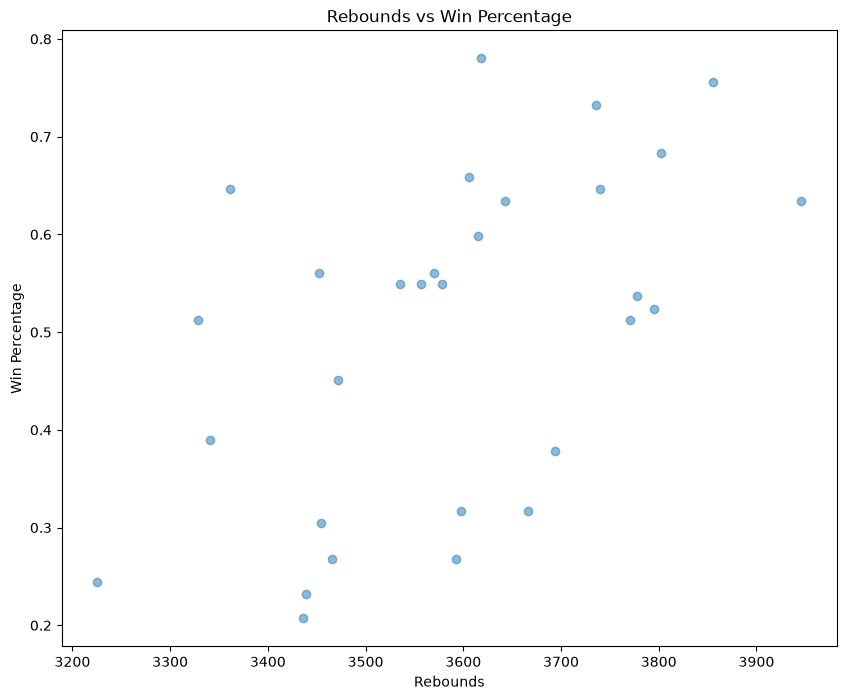

r = 0.515


In [21]:
# REB vs W_PCT
plt.figure(figsize=(10,8))
plt.scatter(df["REB"], df["W_PCT"], alpha=0.5)
plt.xlabel("Rebounds")
plt.ylabel("Win Percentage")
plt.title("Rebounds vs Win Percentage")
plt.show()

r = df["REB"].corr(df["W_PCT"])

print(f"r = {r:.3f}")

In [22]:
df[["TEAM_NAME", "REB", "W_PCT"]].sort_values("REB",ascending= False)

,TEAM_NAME,REB,W_PCT
10,Houston Rockets,3946,0.634
26,San Antonio Spurs,3856,0.756
1,Boston Celtics,3802,0.683
15,Miami Heat,3795,0.524
3,Charlotte Hornets,3778,0.537
24,Portland Trail Blazers,3771,0.512
19,New York Knicks,3740,0.646
8,Detroit Pistons,3736,0.732
4,Chicago Bulls,3694,0.378
6,Dallas Mavericks,3666,0.317


### Histograms

#### W_PCT

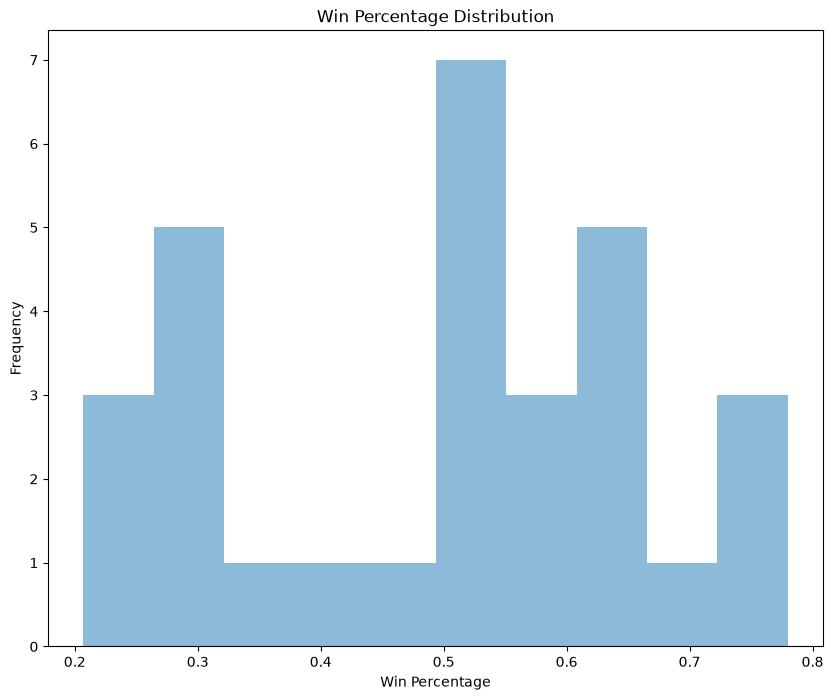

In [23]:
# W_PCT
plt.figure(figsize=(10,8))
plt.hist(df["W_PCT"], alpha=0.5)
plt.xlabel("Win Percentage")
plt.ylabel("Frequency")
plt.title("Win Percentage Distribution")
plt.show()

######  *Most teams lie on further ends of W_PCT range

#### FG_PCT

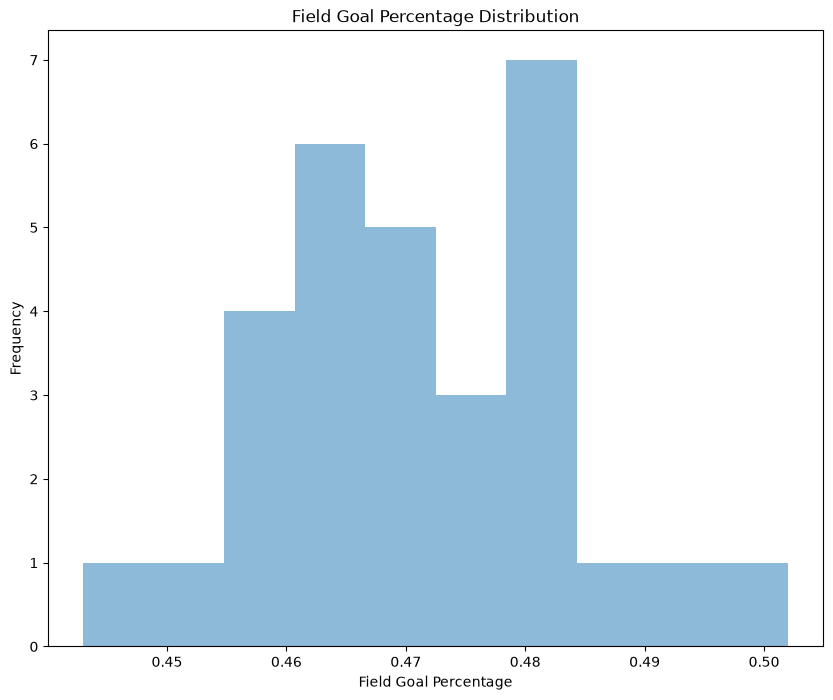

In [24]:
# FG_PCT
plt.figure(figsize=(10,8))
plt.hist(df["FG_PCT"], alpha=0.5)
plt.xlabel("Field Goal Percentage")
plt.ylabel("Frequency")
plt.title("Field Goal Percentage Distribution")
plt.show()

######  *Most teams fall in similar range with minimal on extreme ends

#### FG3_PCT

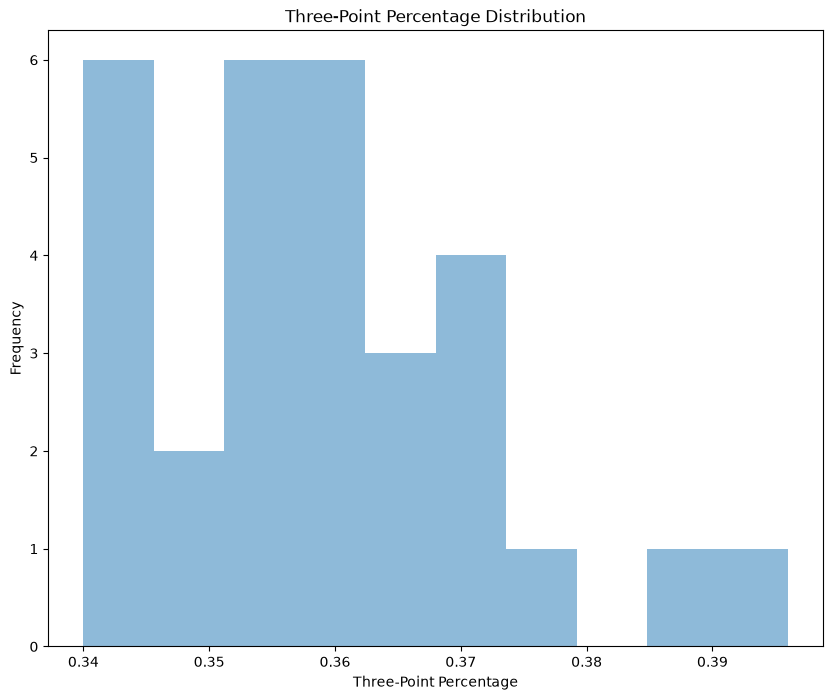

In [25]:
# FG3_PCT
plt.figure(figsize=(10,8))
plt.hist(df["FG3_PCT"], alpha=0.5)
plt.xlabel("Three-Point Percentage")
plt.ylabel("Frequency")
plt.title("Three-Point Percentage Distribution")
plt.show()

######  *FG3_PCG falls lower for most teams, suggesting higher 3 point misses

#### REB

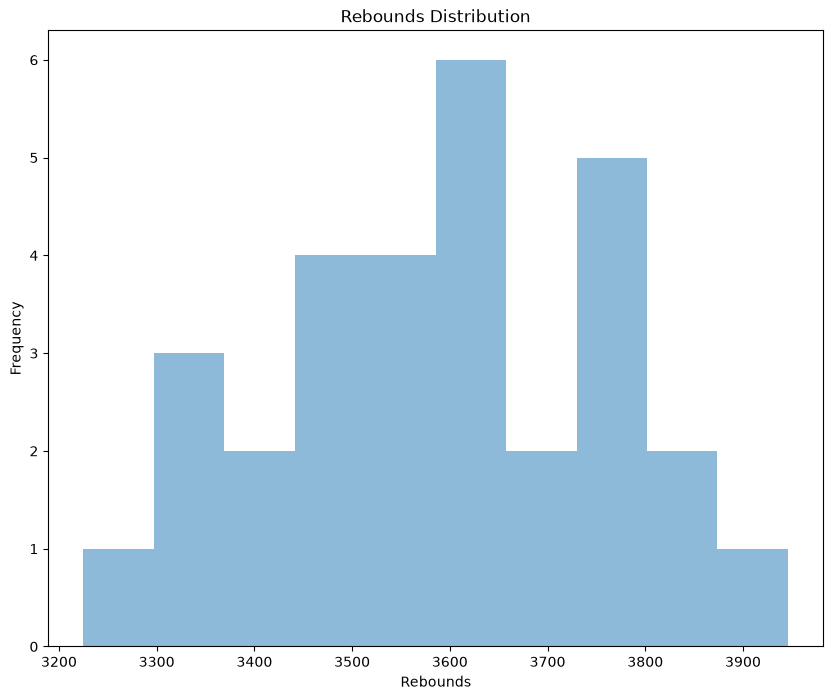

In [26]:
# REB
plt.figure(figsize=(10,8))
plt.hist(df["REB"], alpha=0.5)
plt.xlabel("Rebounds")
plt.ylabel("Frequency")
plt.title("Rebounds Distribution")
plt.show()

#### TOV

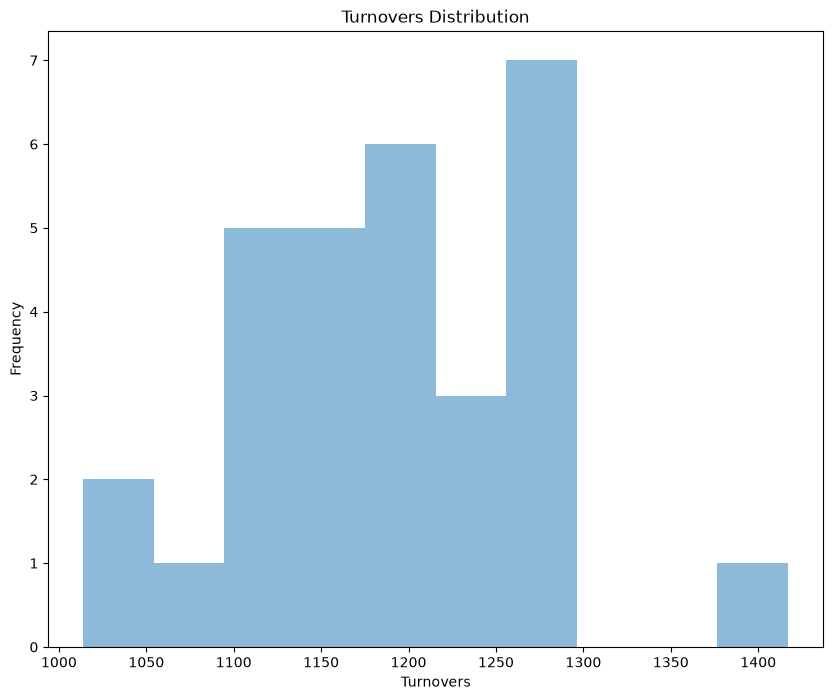

In [27]:
# TOV
plt.figure(figsize=(10,8))
plt.hist(df["TOV"], alpha=0.5)
plt.xlabel("Turnovers")
plt.ylabel("Frequency")
plt.title("Turnovers Distribution")
plt.show()

### Leaderboards(Top 5)

#### W_PCT

In [28]:
df[["TEAM_NAME","W_PCT"]].sort_values("W_PCT",ascending=False).head()

,TEAM_NAME,W_PCT
20,Oklahoma City Thunder,0.780
26,San Antonio Spurs,0.756
8,Detroit Pistons,0.732
1,Boston Celtics,0.683
7,Denver Nuggets,0.659


#### FG_PCT

In [29]:
df[["TEAM_NAME","FG_PCT"]].sort_values("FG_PCT",ascending=False).head()

,TEAM_NAME,FG_PCT
13,Los Angeles Lakers,0.502
7,Denver Nuggets,0.496
8,Detroit Pistons,0.485
20,Oklahoma City Thunder,0.484
12,LA Clippers,0.484


#### FG3_PCT

In [30]:
df[["TEAM_NAME","FG3_PCT"]].sort_values("FG3_PCT",ascending=False).head()

,TEAM_NAME,FG3_PCT
7,Denver Nuggets,0.396
16,Milwaukee Bucks,0.387
3,Charlotte Hornets,0.378
19,New York Knicks,0.373
0,Atlanta Hawks,0.371


#### REB

In [31]:
df[["TEAM_NAME","REB"]].sort_values("REB",ascending=False).head()

,TEAM_NAME,REB
10,Houston Rockets,3946
26,San Antonio Spurs,3856
1,Boston Celtics,3802
15,Miami Heat,3795
3,Charlotte Hornets,3778


#### TOV

In [32]:
df[["TEAM_NAME","TOV"]].sort_values("TOV",ascending=False).head()

,TEAM_NAME,TOV
24,Portland Trail Blazers,1417.0
2,Brooklyn Nets,1292.0
29,Washington Wizards,1284.0
9,Golden State Warriors,1284.0
28,Utah Jazz,1272.0


### Outlier Analysis

#### Milwaukee Bucks

The Milwaukee Bucks represent one of the largest positive shooting outliers in the dataset. The team ranked near the top of the league in both overall field goal percentage (0.477) and three-point percentage (0.387), yet achieved a winning percentage of only 0.390. Based on the positive relationships observed between shooting efficiency and winning, a stronger record would be expected. This suggests that other factors such as defense, turnovers, injuries, or roster construction may have limited team success despite efficient shooting.

#### Chicago Bulls

The Chicago Bulls appear as a rebounding outlier. The team ranked near the top of the league in defensive rebounds and remained among the stronger rebounding teams overall, yet posted a winning percentage of only 0.378. This indicates that rebounding success alone was insufficient to translate into wins and suggests weaknesses in other areas such as scoring efficiency or defensive effectiveness.

#### San Antonio Spurs

The San Antonio Spurs outperform expectations based on shooting metrics alone. While the team did not rank among the league leaders in three-point percentage, it achieved one of the highest winning percentages in the dataset (0.756). The Spurs also ranked near the top of the league in both total and defensive rebounds, suggesting that possession control and defensive performance may have played a larger role in their success than perimeter shooting.

#### Portland Trail Blazers

The Portland Trail Blazers represent a turnover outlier. Despite leading the league in turnovers, the team maintained a winning percentage above .500. Since turnovers exhibited a moderate negative correlation with winning percentage, a weaker record would generally be expected. This suggests that strengths in other areas may have compensated for the team's turnover issues.

# Exploratory Data Analysis Summary

The objective of this exploratory data analysis was to identify relationships between NBA team statistics and team success, measured by winning percentage (W_PCT). Correlation analysis revealed that plus/minus exhibited the strongest positive relationship with winning percentage (r = 0.973), indicating that teams that consistently outscore opponents tend to achieve better records. While this result was expected, plus/minus is largely an outcome metric and may be less useful as a predictive feature.

Among the traditional basketball statistics, points scored (PTS) and field goal percentage (FG_PCT) demonstrated the strongest positive relationships with winning percentage, suggesting that offensive production and shooting efficiency are important drivers of team success. Three-point percentage (FG3_PCT) also showed a positive relationship with winning, although its correlation was weaker than overall field goal percentage. This finding suggests that overall offensive efficiency may be more important than perimeter shooting alone.

Rebounding metrics, particularly defensive rebounds (DREB), displayed moderate positive correlations with winning percentage. Teams that consistently secured rebounds tended to perform better, likely due to increased possession control and reduced second-chance opportunities for opponents. Conversely, turnovers (TOV) showed a moderate negative relationship with winning percentage, reinforcing the importance of ball security and possession management.

Several notable outliers were identified during the analysis. The Milwaukee Bucks exhibited strong shooting efficiency despite a relatively poor winning percentage, while the Chicago Bulls underperformed despite strong rebounding metrics. Additionally, the Portland Trail Blazers maintained a winning percentage above .500 despite leading the league in turnovers. These exceptions demonstrate that team success is influenced by multiple interacting factors and cannot be fully explained by any single statistic.

Overall, the results suggest that offensive efficiency, rebounding, and turnover management are among the most important statistical indicators of team success. These findings will guide feature selection in the next phase of the project, where predictive models will be developed to estimate team performance using historical team statistics.

**Note:** This analysis reflects a snapshot of NBA team performance at the time of data collection. Because the season and playoffs are ongoing, team statistics and relationships may change as additional games are played.


In [33]:
from datetime import date
print(date.today())

2026-08-17


### Data Scope

This analysis is based on NBA team statistics available at the time of data collection. Because the 2025-26 NBA season is still in progress and playoff games continue to be played, team statistics and rankings will change as additional games are completed. Consequently, all findings and conclusions in this notebook should be interpreted as a snapshot of league performance at the time the dataset was collected rather than final season results.


### Limitations

This analysis reflects team performance through the date of data collection. As additional regular season or playoff games are played, statistical values, correlations, and rankings may change.
